In [1]:
import numpy as np
np.random.seed(1337) 
import pandas as pd
import keras
import keras.regularizers
import glob
import os
import itertools
import seaborn as sns


from sklearn.preprocessing import MinMaxScaler, StandardScaler, MaxAbsScaler, Normalizer
from sklearn.metrics import confusion_matrix, recall_score, f1_score, precision_score

from keras_self_attention import SeqSelfAttention
from keras.utils import custom_object_scope

import matplotlib.pyplot as plt

# Import path configuration
import sys
sys.path.insert(0, '..')  # Add parent directory to path
from config import setup_workdir, get_path

2026-03-15 16:50:12.495820: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-15 16:50:12.722641: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-15 16:50:12.727833: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-03-15 16:50:12.727862: I tensorflow/compiler/xla

In [45]:
# Find the best model from cross-validation folds
# Using the no-attention model which showed best interpretability and clean saliency maps

# Choose which model architecture to use:
model_type = 'no_attention'  # Options: 'csd' (with attention), 'no_attention', 'minimal'

if model_type == 'csd':
    # Original model with attention mechanism
    folds_dir = get_path('csd_models') / 'cv_folds'
    fold_pattern = 'csd_fold_*_model.h5'
    use_attention = True
elif model_type == 'no_attention':
    # No-attention model (best interpretability)
    folds_dir = get_path('csd_models').parent / 'csd_no_attention' / 'cv_folds'
    fold_pattern = 'csd_fold_*_model.h5'
    use_attention = False
elif model_type == 'minimal':
    # Minimal architecture model
    folds_dir = get_path('csd_models').parent / 'csd_minimal' / 'cv_folds'
    fold_pattern = 'minimal_fold_*_model.h5'
    use_attention = False
else:
    raise ValueError(f"Unknown model_type: {model_type}")

fold_models = sorted(folds_dir.glob(fold_pattern))

if not fold_models:
    raise FileNotFoundError(f"No fold models found in {folds_dir}")

print(f"Loading {model_type} model")
print(f"Found {len(fold_models)} fold models")

# Load the first fold model (or specify best_fold if known)
#best_model_path = fold_models[0]  # Default to first fold

# If you know the best fold from training notebook 4, you can set it here:
best_fold = 9  # Example: if fold 3 was best
best_model_path = folds_dir / f'csd_fold_{best_fold}_model.h5'

print(f"Loading model: {best_model_path.name}")

if use_attention:
    with custom_object_scope({'SeqSelfAttention': SeqSelfAttention}):
        load_model = keras.models.load_model(best_model_path)
else:
    load_model = keras.models.load_model(best_model_path)

# Set working directory to processed experimental PDFs
setup_workdir('experimental_processed')
files = glob.glob('*processed.gr')

Loading no_attention model
Found 10 fold models
Loading model: csd_fold_9_model.h5
Working directory: /workspace/home/pdf-nn-data/experimental_pdfs/processed


In [46]:
# Load and preprocess experimental PDF data
raw_data_points = []
filenames = []

for f in files:
    df = pd.read_csv(f, usecols=[1], skiprows=1, header=None, delim_whitespace=True, skipfooter=1, engine='python')
    raw_data_points.append(df.values.ravel())
    filenames.append(os.path.basename(f))

raw_data_points = np.array(raw_data_points)

# Normalize the data (same preprocessing as training)
normalize = Normalizer()
data_points = normalize.fit_transform(raw_data_points)

print(f"Loaded {len(data_points)} PDF files for prediction")

Loaded 19 PDF files for prediction


In [47]:
# Run predictions
y_pred_prob = load_model.predict(data_points)

# Get top 2 predictions for each sample
top2_indices = np.argsort(y_pred_prob, axis=1)[:, -2:][:, ::-1]  # Top 2, descending
top2_probs = np.take_along_axis(y_pred_prob, top2_indices, axis=1)

# Map predictions to nuclearity labels
# Model trained with labels 1-9 (nuclearity) and 10 (polymer)
def pred_to_nuclearity(pred):
    if pred == 10:
        return "polymer"
    else:
        return str(pred)

def clip_filename(fname, max_len=32):
    """Truncate filename if too long, adding ellipsis."""
    if len(fname) > max_len:
        return fname[:max_len-3] + "..."
    return fname

# Display results
print("=" * 85)
print("PREDICTION RESULTS")
print("=" * 85)
print(f"\n{'Filename':<32} {'1st Prediction':>14} {'Conf.':>8} {'2nd Prediction':>14} {'Conf.':>8}")
print("-" * 85)

results = []
for i, fname in enumerate(filenames):
    pred1 = top2_indices[i, 0]
    pred2 = top2_indices[i, 1]
    conf1 = top2_probs[i, 0]
    conf2 = top2_probs[i, 1]
    
    nuc1 = pred_to_nuclearity(pred1)
    nuc2 = pred_to_nuclearity(pred2)
    
    display_name = clip_filename(fname)
    print(f"{display_name:<32} {nuc1:>14} {conf1:>7.1%} {nuc2:>14} {conf2:>7.1%}")
    results.append({
        'filename': fname,  # Keep full filename in CSV
        'prediction_1': nuc1, 
        'confidence_1': conf1,
        'prediction_2': nuc2,
        'confidence_2': conf2
    })

# Save predictions to CSV
results_df = pd.DataFrame(results)
output_path = get_path('labels') / 'predictions.csv'
results_df.to_csv(output_path, index=False)
print(f"\nPredictions saved to: {output_path}")

1/1 [==============================] - 0s 108ms/step
PREDICTION RESULTS

Filename                         1st Prediction    Conf. 2nd Prediction    Conf.
-------------------------------------------------------------------------------------
Dy4(OH)2(piv)10(H2O)2_process...        polymer   97.4%              8    1.4%
Sm4(OH)2(piv)10_processed.gr                  4   87.8%        polymer    6.8%
Gd(tfa)3-deta-iPrOH_processed.gr              4   40.9%        polymer   32.4%
Tb4(OH)2(piv)10(H2O)2_process...        polymer   73.1%              4   11.6%
Gd(tfa)3-mea-iPrOH_processed.gr               4   97.8%              8    2.1%
Nd4(OH)2(piv)10(H2O)2_process...              4   28.2%              5   17.0%
Gd4(OH)2(piv)10(H2O)2_process...              4   78.1%              6    6.2%
Ho4(OH)2(piv)10_processed.gr            polymer   93.6%              4    4.4%
Ce4(OH)2(piv)10(H2O)2_process...        polymer   77.1%              2   10.5%
Nd4(OH)2(piv)10_processed.gr                  4  

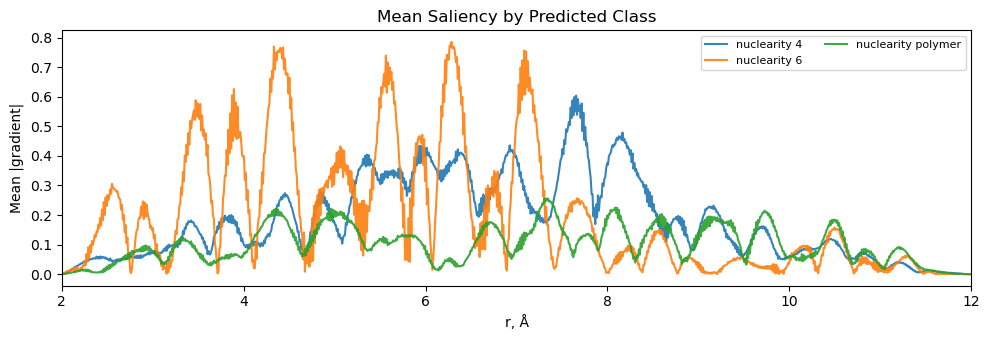

In [48]:
# Gradient saliency for predicted class
import tensorflow as tf

# Recreate missing dependencies if upstream cells were removed
if 'y_pred_prob' not in globals():
    y_pred_prob = load_model.predict(data_points, verbose=0)
pred_classes = np.argmax(y_pred_prob, axis=1)

if 'pred_to_nuclearity' not in globals():
    def pred_to_nuclearity(pred):
        if pred == 10:
            return 'polymer'
        return str(pred)

x_tensor = tf.convert_to_tensor(data_points.astype(np.float32))

with tf.GradientTape() as tape:
    tape.watch(x_tensor)
    preds = load_model(x_tensor, training=False)
    pred_idx = tf.argmax(preds, axis=1, output_type=tf.int32)
    row_idx = tf.range(tf.shape(preds)[0], dtype=tf.int32)
    gather_idx = tf.stack([row_idx, pred_idx], axis=1)
    target_scores = tf.gather_nd(preds, gather_idx)

# d(score_predicted_class) / d(input)
grads = tape.gradient(target_scores, x_tensor).numpy()
saliency = np.abs(grads)

# Use physical r-axis (Angstrom) to match plotting in the next cell
x_axis = np.linspace(2.0, 12.0, saliency.shape[1])

# Saliency by predicted class
saliency_df = pd.DataFrame({'r_angstrom': x_axis})
for cls in np.unique(pred_classes):
    cls_mask = pred_classes == cls
    if np.any(cls_mask):
        saliency_df[f'nuclearity {pred_to_nuclearity(cls)}'] = saliency[cls_mask].mean(axis=0)

plt.figure(figsize=(10, 3.5))
for col in saliency_df.columns[1:]:
    plt.plot(saliency_df['r_angstrom'], saliency_df[col], label=col, alpha=0.9)
plt.title('Mean Saliency by Predicted Class')
plt.xlabel('r, Å')
plt.ylabel('Mean |gradient|')
plt.xlim(2.0, 12.0)
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

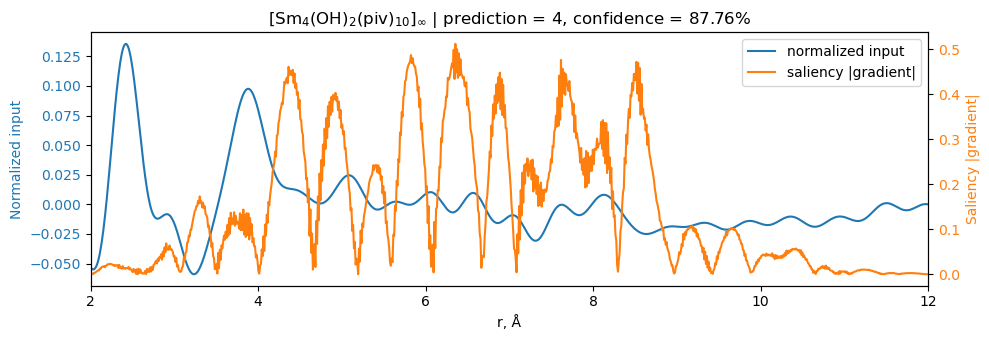

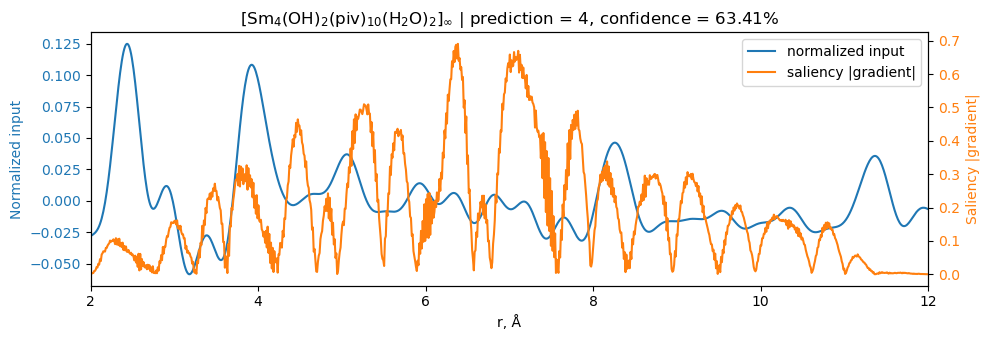

In [49]:
# Example saliency plots for selected structures
if 'y_pred_prob' not in globals():
    y_pred_prob = load_model.predict(data_points, verbose=0)
if 'pred_classes' not in globals():
    pred_classes = np.argmax(y_pred_prob, axis=1)
if 'saliency' not in globals() or 'grads' not in globals():
    import tensorflow as tf
    x_tensor = tf.convert_to_tensor(data_points.astype(np.float32))
    with tf.GradientTape() as tape:
        tape.watch(x_tensor)
        preds = load_model(x_tensor, training=False)
        pred_idx = tf.argmax(preds, axis=1, output_type=tf.int32)
        row_idx = tf.range(tf.shape(preds)[0], dtype=tf.int32)
        gather_idx = tf.stack([row_idx, pred_idx], axis=1)
        target_scores = tf.gather_nd(preds, gather_idx)
    grads = tape.gradient(target_scores, x_tensor).numpy()
    saliency = np.abs(grads)
if 'pred_to_nuclearity' not in globals():
    def pred_to_nuclearity(pred):
        if pred == 10:
            return 'polymer'
        return str(pred)

prefix_to_hardcoded_title = {
    'Sm4(OH)2(piv)10(H2O)2_processed': r"[Sm$_{4}$(OH)$_{2}$(piv)$_{10}$(H$_{2}$O)$_{2}$]$_{\infty}$",
    'Sm4(OH)2(piv)10_processed': r"[Sm$_{4}$(OH)$_{2}$(piv)$_{10}$]$_{\infty}$",
}

selected_indices = [
    i for i, fname in enumerate(filenames)
    if any(fname.startswith(prefix) for prefix in prefix_to_hardcoded_title)
]

x_axis = np.linspace(2.0, 12.0, data_points.shape[1])

if not selected_indices:
    print('No files matched the configured prefixes.')
else:
    for sample_idx in selected_indices:
        fname = filenames[sample_idx]

        hardcoded_name = None
        for prefix, title_text in prefix_to_hardcoded_title.items():
            if fname.startswith(prefix):
                hardcoded_name = title_text
                break

        fig, ax_left = plt.subplots(figsize=(10, 3.5))
        ax_right = ax_left.twinx()

        line_data, = ax_left.plot(
            x_axis, data_points[sample_idx],
            color='tab:blue', label='normalized input', alpha=1
        )
        line_sal, = ax_right.plot(
            x_axis, saliency[sample_idx],
            color='tab:orange', label='saliency |gradient|', alpha=1
        )

        ax_left.set_title(
            f"{hardcoded_name} | prediction = {pred_to_nuclearity(pred_classes[sample_idx])}, "
            f"confidence = {np.max(y_pred_prob[sample_idx]):.2%}"
        )
        ax_left.set_xlabel('r, Å')
        ax_left.set_ylabel('Normalized input', color='tab:blue')
        ax_right.set_ylabel('Saliency |gradient|', color='tab:orange')

        ax_left.tick_params(axis='y', labelcolor='tab:blue')
        ax_right.tick_params(axis='y', labelcolor='tab:orange')
        ax_left.set_xlim(2.0, 12.0)

        ax_left.legend([line_data, line_sal], ['normalized input', 'saliency |gradient|'], loc='upper right')

        plt.tight_layout()
        plt.show()

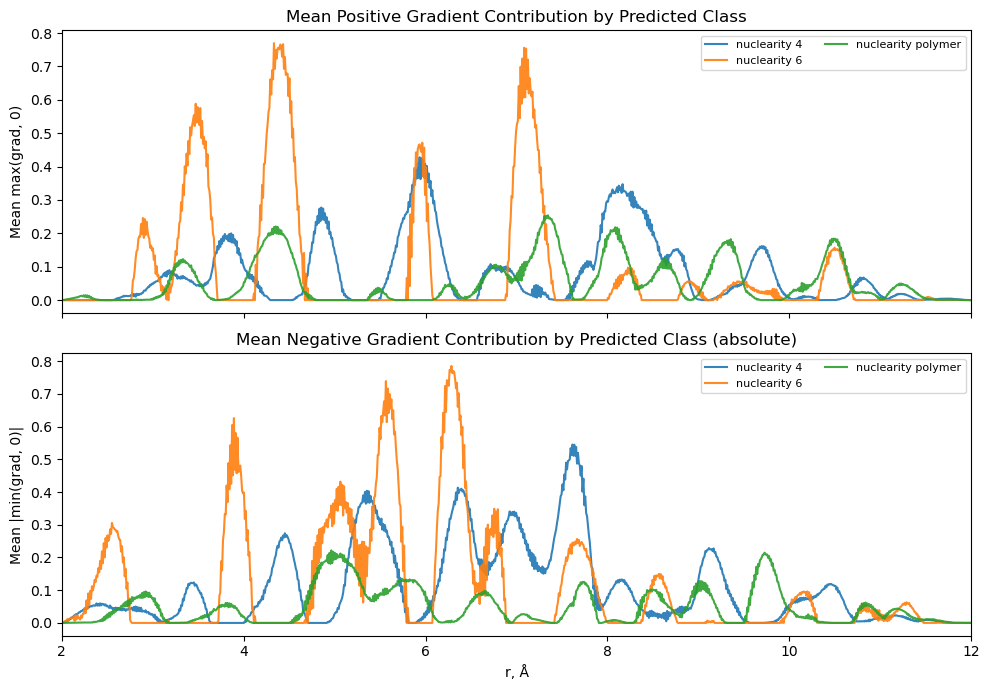

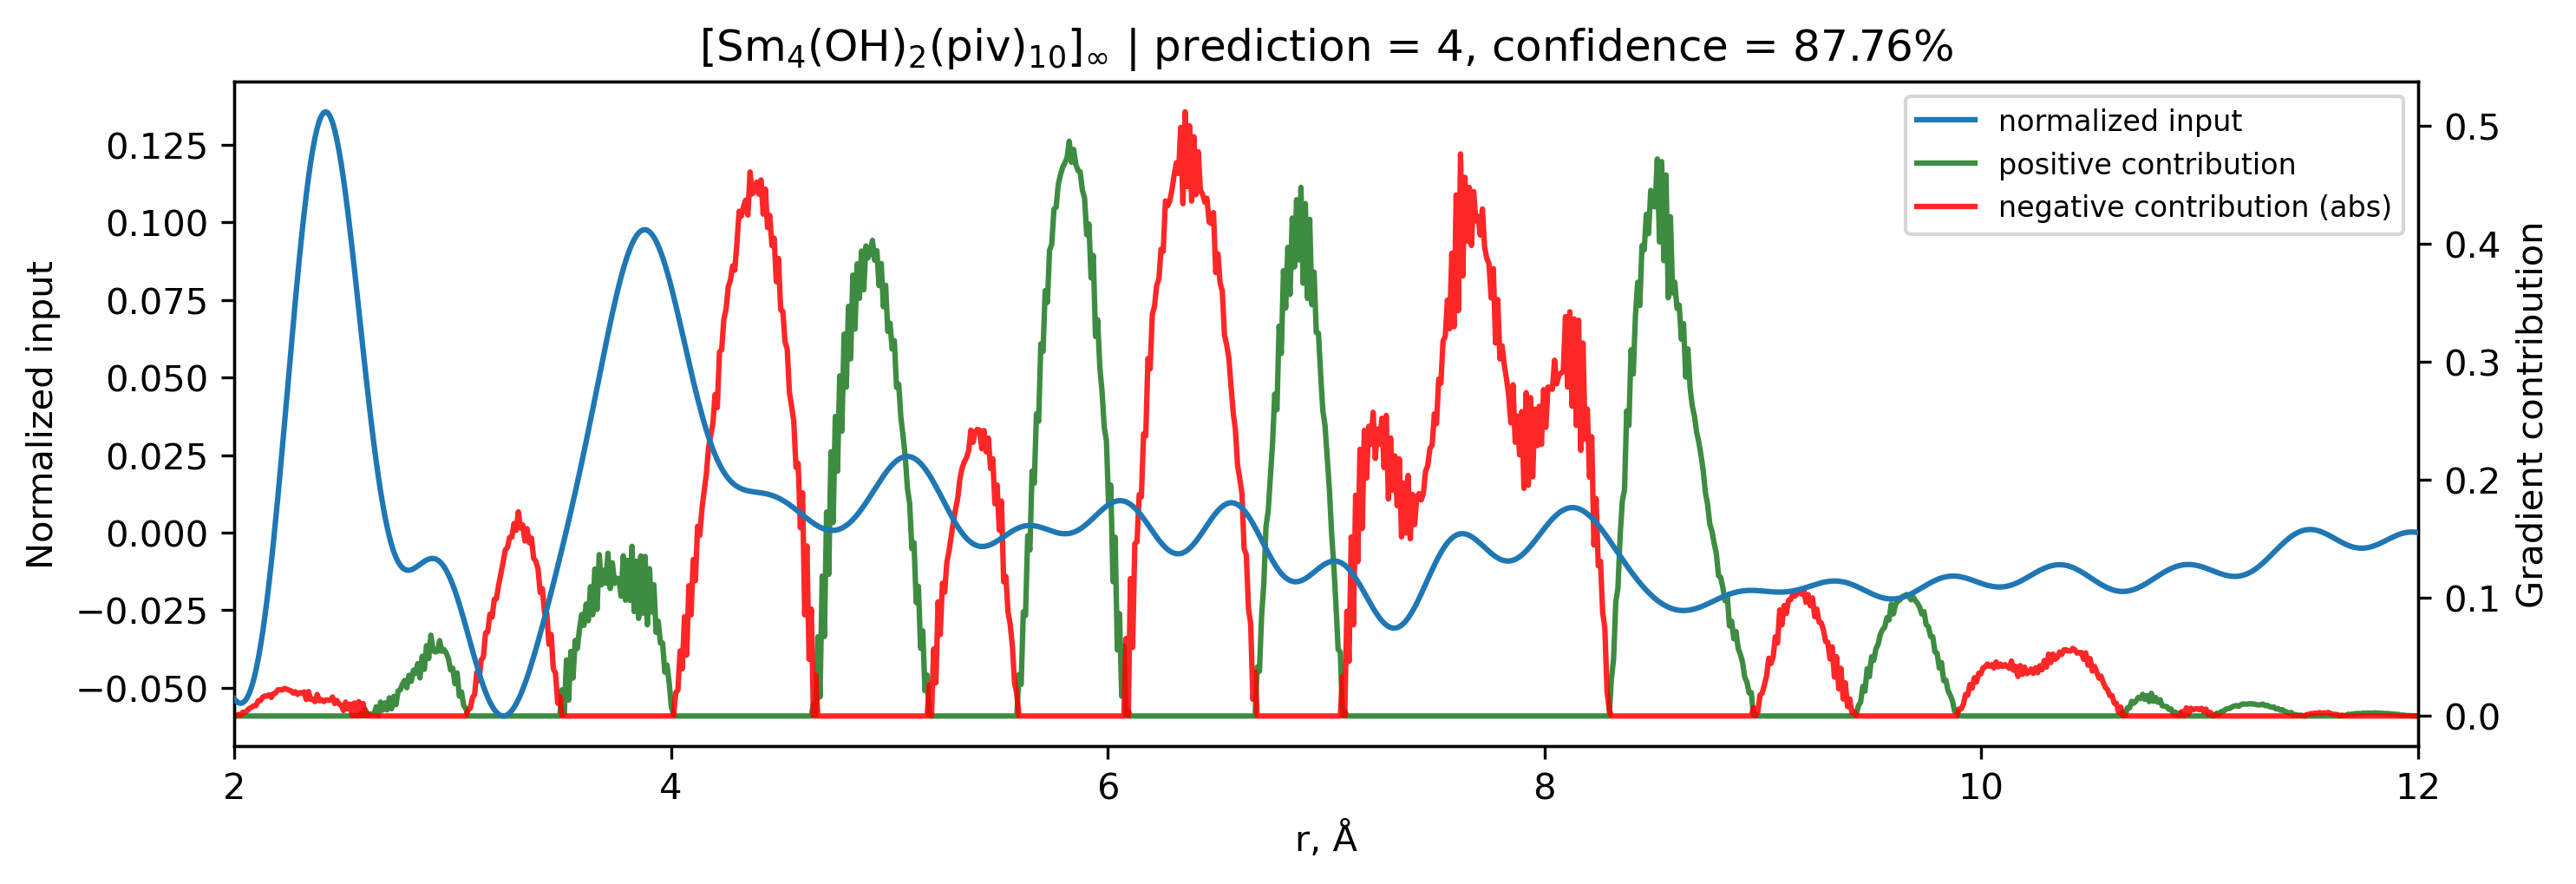

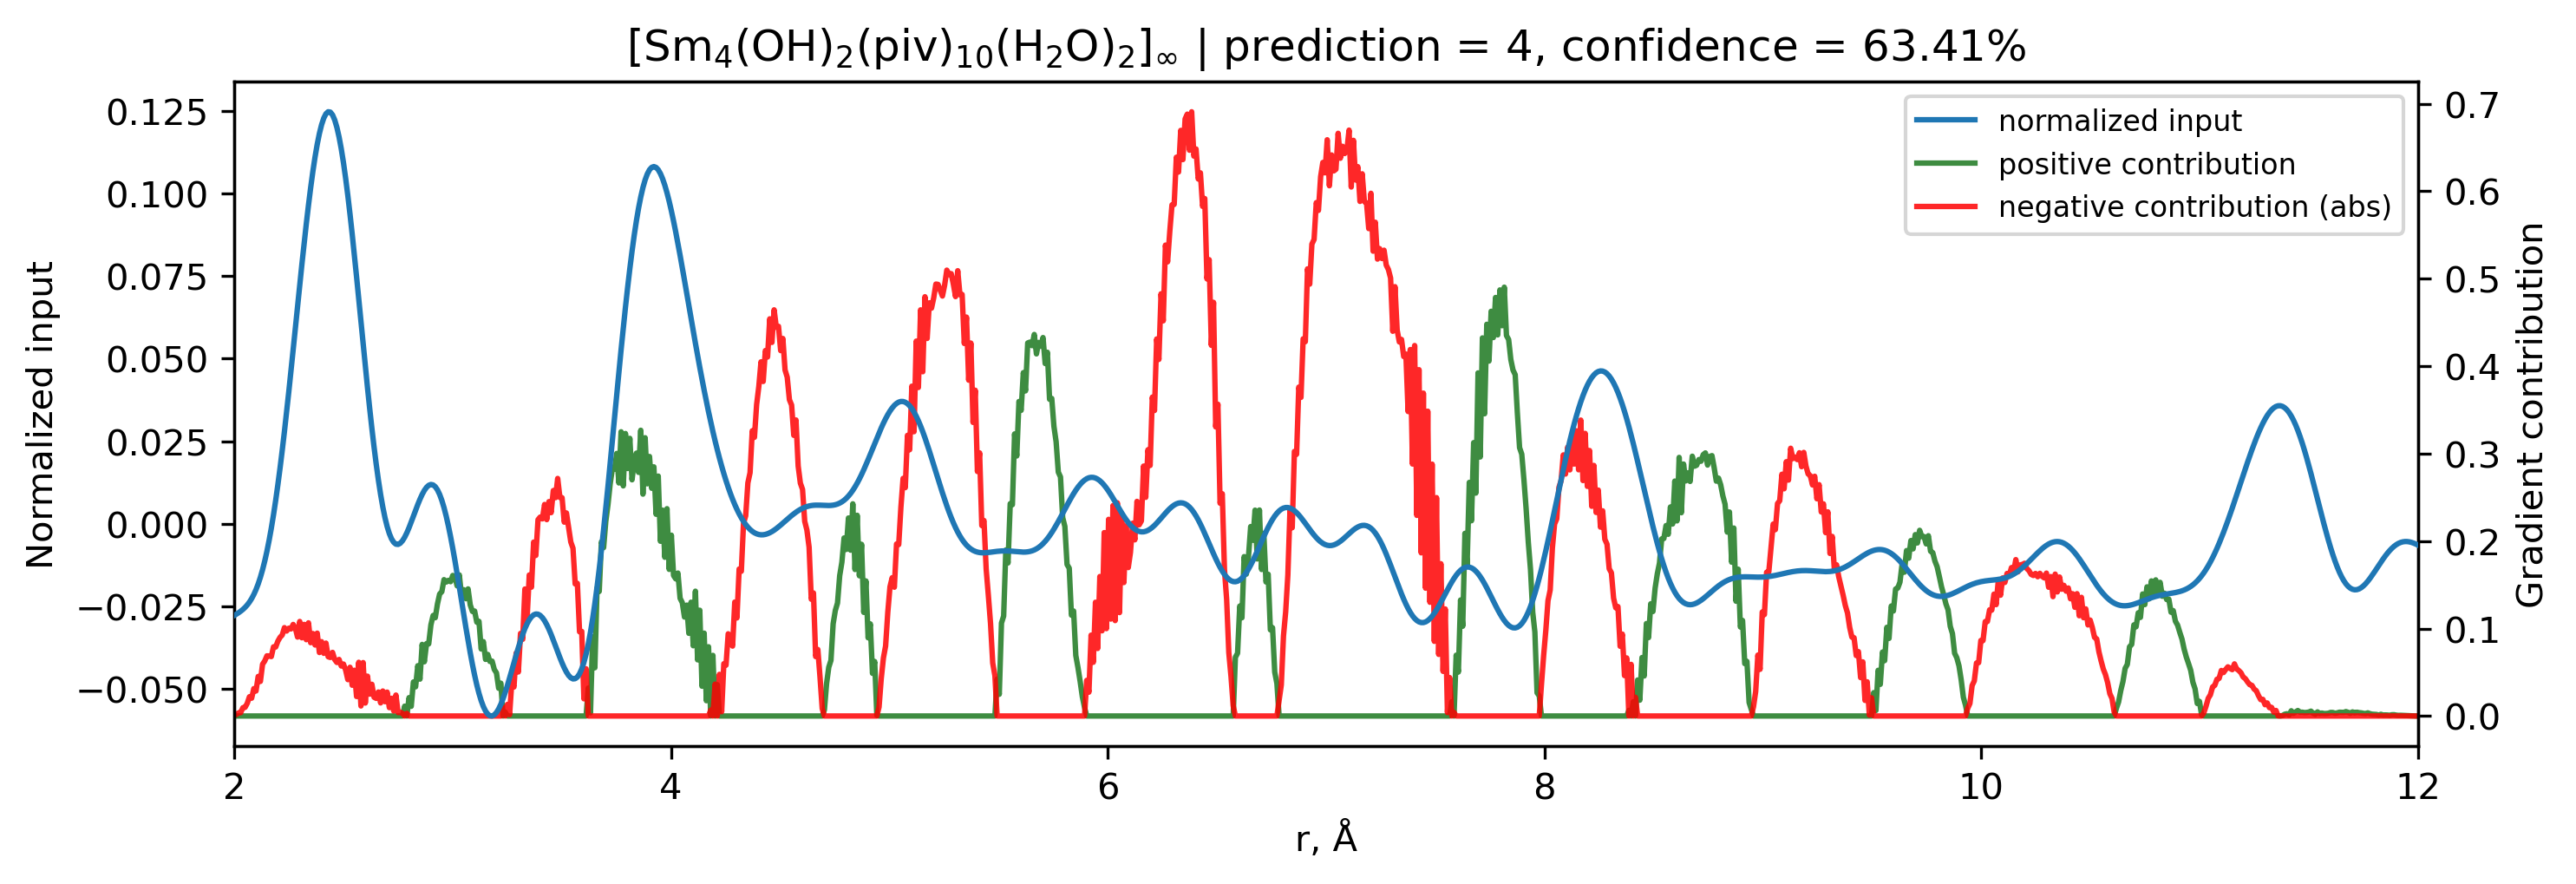

In [50]:
# Signed-gradient decomposition: positive and negative contributions
# positive part  = max(grad, 0)
# negative part  = abs(min(grad, 0))
if 'y_pred_prob' not in globals():
    y_pred_prob = load_model.predict(data_points, verbose=0)
if 'pred_classes' not in globals():
    pred_classes = np.argmax(y_pred_prob, axis=1)
if 'grads' not in globals():
    import tensorflow as tf
    x_tensor = tf.convert_to_tensor(data_points.astype(np.float32))
    with tf.GradientTape() as tape:
        tape.watch(x_tensor)
        preds = load_model(x_tensor, training=False)
        pred_idx = tf.argmax(preds, axis=1, output_type=tf.int32)
        row_idx = tf.range(tf.shape(preds)[0], dtype=tf.int32)
        gather_idx = tf.stack([row_idx, pred_idx], axis=1)
        target_scores = tf.gather_nd(preds, gather_idx)
    grads = tape.gradient(target_scores, x_tensor).numpy()
if 'pred_to_nuclearity' not in globals():
    def pred_to_nuclearity(pred):
        if pred == 10:
            return 'polymer'
        return str(pred)
if 'prefix_to_hardcoded_title' not in globals():
    prefix_to_hardcoded_title = {
        'DF211_processed': r"[Sm$_{4}$(OH)$_{2}$(piv)$_{10}$(H$_{2}$O)$_{2}$]$_{\infty}$",
        'DF211dr_0.1': r"[Sm$_{4}$(OH)$_{2}$(piv)$_{10}$]$_{\infty}$",
    }

grads_pos = np.maximum(grads, 0.0)
grads_neg_abs = np.abs(np.minimum(grads, 0.0))
x_axis_signed = np.linspace(2.0, 12.0, grads.shape[1])

# 1) Mean positive/negative contributions by predicted class
pos_df = pd.DataFrame({'r_angstrom': x_axis_signed})
neg_df = pd.DataFrame({'r_angstrom': x_axis_signed})

for cls in np.unique(pred_classes):
    cls_mask = pred_classes == cls
    if np.any(cls_mask):
        class_name = pred_to_nuclearity(cls)
        pos_df[f'nuclearity {class_name}'] = grads_pos[cls_mask].mean(axis=0)
        neg_df[f'nuclearity {class_name}'] = grads_neg_abs[cls_mask].mean(axis=0)

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

for col in pos_df.columns[1:]:
    axes[0].plot(pos_df['r_angstrom'], pos_df[col], label=col, alpha=0.9)
axes[0].set_title('Mean Positive Gradient Contribution by Predicted Class')
axes[0].set_ylabel('Mean max(grad, 0)')
axes[0].set_xlim(2.0, 12.0)
axes[0].legend(ncol=2, fontsize=8)

for col in neg_df.columns[1:]:
    axes[1].plot(neg_df['r_angstrom'], neg_df[col], label=col, alpha=0.9)
axes[1].set_title('Mean Negative Gradient Contribution by Predicted Class (absolute)')
axes[1].set_xlabel('r, Å')
axes[1].set_ylabel('Mean |min(grad, 0)|')
axes[1].set_xlim(2.0, 12.0)
axes[1].legend(ncol=2, fontsize=8)

plt.tight_layout()
plt.show()

# 2) Same two selected examples with positive and negative contributions
selected_indices_signed = [
    i for i, fname in enumerate(filenames)
    if any(fname.startswith(prefix) for prefix in prefix_to_hardcoded_title)
]

if not selected_indices_signed:
    print('No files matched the configured prefixes for example plots.')
else:
    for sample_idx in selected_indices_signed:
        fname = filenames[sample_idx]

        hardcoded_name = None
        for prefix, title_text in prefix_to_hardcoded_title.items():
            if fname.startswith(prefix):
                hardcoded_name = title_text
                break

        fig, ax_left = plt.subplots(figsize=(10, 3.5), dpi=300)
        ax_right = ax_left.twinx()

        line_pos, = ax_right.plot(
            x_axis_signed, grads_pos[sample_idx],
            color="#1C7820", label='positive contribution', alpha=0.85, zorder=2
        )
        line_neg, = ax_right.plot(
            x_axis_signed, grads_neg_abs[sample_idx],
            color='#FE0102', label='negative contribution (abs)', alpha=0.85, zorder=2
        )

        # Keep left axis and blue line above right-axis saliency lines
        ax_left.set_zorder(ax_right.get_zorder() + 1)
        ax_left.patch.set_visible(False)
        line_data, = ax_left.plot(
            x_axis_signed, data_points[sample_idx],
            color='tab:blue', label='normalized input', alpha=1, zorder=5
        )

        ax_left.set_title(
            f"{hardcoded_name} | prediction = {pred_to_nuclearity(pred_classes[sample_idx])}, "
            f"confidence = {np.max(y_pred_prob[sample_idx]):.2%}"
        )
        ax_left.set_xlabel('r, Å')
        ax_left.set_ylabel('Normalized input', color='black')
        ax_right.set_ylabel('Gradient contribution', color='black')

        ax_left.tick_params(axis='y', labelcolor='black')
        ax_right.tick_params(axis='y', labelcolor='black')
        ax_left.set_xlim(2.0, 12.0)

        ax_left.legend(
            [line_data, line_pos, line_neg],
            ['normalized input', 'positive contribution', 'negative contribution (abs)'],
            loc='upper right',
            fontsize=8
        )

        plt.tight_layout()
        plt.show()